In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from bbg_utils.bdh_mm import bdh_mm
from bbg_utils.bdp_mm import bdp_mm
cds_mappings = pd.read_csv(r"S:\Structured Credit\Matt Stuff\cds_mappings\cds_mappings_final.csv", encoding="cp1252")
cds_mappings.head(5)

,CDS_Curve_ID,CDS_Ticker,Markit_CDS_Ticker,Markit_Currency,Markit_Doc_Clause,Markit_Seniority,Markit_Coupon_Lookup,BBG_Coupon_Dupe,Coupon_Mismatch,Coupon_Override,...,BBG_Equity_Ticker,Eq_Ticker_Company_Name,Company_Private,Ultimate_Parent_Equity_Ticker,Ultimate_Parent_Private,CDS_Public_Equity_Entity_Ticker,Best_Bond_Proxy_ISIN,Best_Bond_Proxy_Note,Markit_Ticker_Lookup_BBG_RedCode,Markit_Ticker_Mismatch
0,1,AAL,AMERAIAI,USD,XR14,SNRFOR,500.0,500.0,NaN,NaN,...,AAL US Equity,AMERICAN AIRLINES GROUP INC,N,AAL US Equity,N,AAL US Equity,US023771T329,NaN,AMERAIAI,NaN
1,2,ADT,THADT,USD,XR14,SNRFOR,500.0,500.0,NaN,NaN,...,1566019D US Equity,ADT SECURITY CORP/THE,Y,ADT US Equity,N,ADT US Equity,USU0073MAA81,NaN,THADT,NaN
2,3,ALIANT,ALLIHOAH,USD,XR14,SNRFOR,100.0,500.0,1.0,500.0,...,1426133D US Equity,ALLIANT HOLDINGS INTERMEDIAT,Y,1339681D US Equity,Y,NaN,USU0188CAH70,NaN,ALLIHOAH,NaN
3,4,AMKR,AMKR,USD,XR14,SNRFOR,500.0,500.0,NaN,NaN,...,AMKR US Equity,AMKOR TECHNOLOGY INC,N,AMKR US Equity,N,AMKR US Equity,NaN,NaN,AMKR,NaN
4,5,ARMK,ARAMSER,USD,XR14,SNRFOR,500.0,500.0,NaN,NaN,...,2387Z US Equity,ARAMARK SERVICES INC,Y,ARMK US Equity,N,ARMK US Equity,USU0389LAE12,NaN,ARAMSER,NaN


In [2]:
from databricks_utils import get_delta_table_mm

CACHE_DIR = r"S:\Structured Credit\Matt Stuff\claude_repos\cds_bond_basis\cache"

CDS_TRANSFORM_COLUMNS = [
    "published_date",
    "market_cds_ticker",
    "tenor",
    "cds_maturity",
    "cds_index",
    "tier",
    "currency",
    "doc_clause",
    "running_coupon",
    "par_spread",
    "conv_spread",
    "upfront",
    "cds_assumed_recovery",
    "all_upfront",
]

cds_transform_interpolated = get_delta_table_mm(
    "teams.structured_credit_abhutra.cds_transform_interpolated",
    cache_dir=CACHE_DIR,
    columns=CDS_TRANSFORM_COLUMNS,
    where="published_date >= '2025-01-01'",
    filename="cds_transform_interpolated_subset_2025.parquet",
)

[cache] cds_transform_interpolated_subset_2025.parquet is current — loading from disk


In [3]:
print(cds_transform_interpolated.shape)
cds_transform_interpolated.head(5)

(3615815, 14)


,published_date,market_cds_ticker,tenor,cds_maturity,cds_index,tier,currency,doc_clause,running_coupon,par_spread,conv_spread,upfront,cds_assumed_recovery,all_upfront
0,2026-07-07,ARGID,6M,2026-12-20,XO,SNRFOR,EUR,MM14,500.0,694.9151,695.2141,0.8697,0.4,3.1197
1,2026-07-07,ARGID,1Y,2027-06-20,XO,SNRFOR,EUR,MM14,500.0,900.7357,905.4281,3.5983,0.4,8.0983
2,2026-07-07,ARGID,1Y6M,2027-12-20,XO,SNRFOR,EUR,MM14,500.0,871.3914,874.9853,4.8281,0.4,11.3281
3,2026-07-07,ARGID,2Y,2028-06-20,XO,SNRFOR,EUR,MM14,500.0,842.0471,844.5425,5.8178,0.4,14.3178
4,2026-07-07,ARGID,2Y6M,2028-12-20,XO,SNRFOR,EUR,MM14,500.0,852.1410,856.1631,7.1837,0.4,17.3837


In [4]:
cds_mappings_filtered = (
    cds_mappings
    .dropna(subset=["Best_Bond_Proxy_ISIN"])
    [["CDS_Ticker", "CDS_Index", "Best_Bond_Proxy_ISIN"]]
    .rename(columns={"CDS_Ticker": "ticker", "CDS_Index": "cds_index", "Best_Bond_Proxy_ISIN": "BOND_ISIN"})
    .reset_index(drop=True)
)
print(cds_mappings_filtered.shape)
cds_mappings_filtered.head(5)

(374, 3)


,ticker,cds_index,BOND_ISIN
0,AAL,HY,US023771T329
1,ADT,HY,USU0073MAA81
2,ALIANT,HY,USU0188CAH70
3,ARMK,HY,USU0389LAE12
4,ASH,HY,USU0442LAA45


In [5]:
bonds = cds_mappings_filtered.copy()
bonds["security"] = bonds["BOND_ISIN"] + " Corp"

bond_history = bdh_mm(
    bonds["security"],
    ["LAST_PRICE", "BLP_SPRD_TO_BENCH_MID", "BLOOMBERG_MID_G_SPREAD"],
    start_date="2025-01-01",
)
print(bond_history.shape)
bond_history.head(5)

(131583, 5)


,security,date,LAST_PRICE,BLP_SPRD_TO_BENCH_MID,BLOOMBERG_MID_G_SPREAD
0,BE6364524635 Corp,2026-07-08,98.700,67.223,65.548
1,DE000A4DFLQ6 Corp,2026-07-08,104.883,138.109,135.655
2,FI4000590864 Corp,2026-07-08,96.788,184.608,180.265
3,FR0011270487 Corp,2026-07-08,85.207,429.798,427.434
4,FR0014002OL8 Corp,2026-07-08,98.599,68.315,64.007


In [6]:
bond_maturity = bdp_mm(bonds["security"], ["MATURITY", "SECURITY_NAME"])
bond_maturity["MATURITY"] = pd.to_datetime(bond_maturity["MATURITY"])
bond_maturity.head(5)

,security,MATURITY,SECURITY_NAME
0,BE6364524635 Corp,2033-05-19,ABIBB 3 3/8 05/19/33
1,DE000A4DFLQ6 Corp,2031-04-01,SHAEFF 5 3/8 04/01/31
2,FI4000590864 Corp,2031-05-28,METSA 3 7/8 05/28/31
3,FR0011270487 Corp,2032-06-14,FTI 4 06/14/32
4,FR0014002OL8 Corp,2028-04-01,RENAUL 2 1/2 04/01/28


In [7]:
from datetime import date

def next_cds_maturity(maturity):
    """First standard semi-annual CDS maturity (20-Jun or 20-Dec) strictly after `maturity`."""
    maturity = pd.Timestamp(maturity).date()
    candidates = sorted(
        date(y, m, 20)
        for y in (maturity.year, maturity.year + 1)
        for m in (6, 12)
    )
    return next(c for c in candidates if c > maturity)

bond_maturity["target_cds_maturity"] = bond_maturity["MATURITY"].apply(next_cds_maturity)

bond_history = bond_history.merge(bond_maturity, on="security", how="left")
bond_history = bond_history.merge(bonds[["security", "ticker", "cds_index"]], on="security", how="left")

print(bond_history.shape)
bond_history.head(5)

(131583, 10)


,security,date,LAST_PRICE,BLP_SPRD_TO_BENCH_MID,BLOOMBERG_MID_G_SPREAD,MATURITY,SECURITY_NAME,target_cds_maturity,ticker,cds_index
0,BE6364524635 Corp,2026-07-08,98.700,67.223,65.548,2033-05-19,ABIBB 3 3/8 05/19/33,2033-06-20,ABIBB,Main
1,DE000A4DFLQ6 Corp,2026-07-08,104.883,138.109,135.655,2031-04-01,SHAEFF 5 3/8 04/01/31,2031-06-20,SHAEFF,XO
2,FI4000590864 Corp,2026-07-08,96.788,184.608,180.265,2031-05-28,METSA 3 7/8 05/28/31,2031-06-20,METSA,XO
3,FR0011270487 Corp,2026-07-08,85.207,429.798,427.434,2032-06-14,FTI 4 06/14/32,2032-06-20,FTI,Other
4,FR0014002OL8 Corp,2026-07-08,98.599,68.315,64.007,2028-04-01,RENAUL 2 1/2 04/01/28,2028-06-20,RENAUL,XO


In [8]:
bond_history = bond_history.merge(
    cds_transform_interpolated[["market_cds_ticker", "published_date", "cds_maturity", "conv_spread", "upfront"]],
    left_on=["ticker", "date", "target_cds_maturity"],
    right_on=["market_cds_ticker", "published_date", "cds_maturity"],
    how="left",
).drop(columns=["market_cds_ticker", "published_date", "cds_maturity"])

print(bond_history.shape)
bond_history.head(5)

(131583, 12)


,security,date,LAST_PRICE,BLP_SPRD_TO_BENCH_MID,BLOOMBERG_MID_G_SPREAD,MATURITY,SECURITY_NAME,target_cds_maturity,ticker,cds_index,conv_spread,upfront
0,BE6364524635 Corp,2026-07-08,98.700,67.223,65.548,2033-05-19,ABIBB 3 3/8 05/19/33,2033-06-20,ABIBB,Main,NaN,NaN
1,DE000A4DFLQ6 Corp,2026-07-08,104.883,138.109,135.655,2031-04-01,SHAEFF 5 3/8 04/01/31,2031-06-20,SHAEFF,XO,NaN,NaN
2,FI4000590864 Corp,2026-07-08,96.788,184.608,180.265,2031-05-28,METSA 3 7/8 05/28/31,2031-06-20,METSA,XO,NaN,NaN
3,FR0011270487 Corp,2026-07-08,85.207,429.798,427.434,2032-06-14,FTI 4 06/14/32,2032-06-20,FTI,Other,NaN,NaN
4,FR0014002OL8 Corp,2026-07-08,98.599,68.315,64.007,2028-04-01,RENAUL 2 1/2 04/01/28,2028-06-20,RENAUL,XO,NaN,NaN


In [9]:
bond_history["basis_spread"] =  bond_history["conv_spread"] - bond_history["BLOOMBERG_MID_G_SPREAD"]
bond_history["basis_price"] =  bond_history["upfront"] + bond_history["LAST_PRICE"]
bond_history = bond_history.rename(columns={
    "BLP_SPRD_TO_BENCH_MID":"Benchmark_Spread",
    "BLOOMBERG_MID_G_SPREAD":"G_Spread",
    "conv_spread":"cds_spread",
})

bond_history.head(5)

,security,date,LAST_PRICE,Benchmark_Spread,G_Spread,MATURITY,SECURITY_NAME,target_cds_maturity,ticker,cds_index,cds_spread,upfront,basis_spread,basis_price
0,BE6364524635 Corp,2026-07-08,98.700,67.223,65.548,2033-05-19,ABIBB 3 3/8 05/19/33,2033-06-20,ABIBB,Main,NaN,NaN,NaN,NaN
1,DE000A4DFLQ6 Corp,2026-07-08,104.883,138.109,135.655,2031-04-01,SHAEFF 5 3/8 04/01/31,2031-06-20,SHAEFF,XO,NaN,NaN,NaN,NaN
2,FI4000590864 Corp,2026-07-08,96.788,184.608,180.265,2031-05-28,METSA 3 7/8 05/28/31,2031-06-20,METSA,XO,NaN,NaN,NaN,NaN
3,FR0011270487 Corp,2026-07-08,85.207,429.798,427.434,2032-06-14,FTI 4 06/14/32,2032-06-20,FTI,Other,NaN,NaN,NaN,NaN
4,FR0014002OL8 Corp,2026-07-08,98.599,68.315,64.007,2028-04-01,RENAUL 2 1/2 04/01/28,2028-06-20,RENAUL,XO,NaN,NaN,NaN,NaN


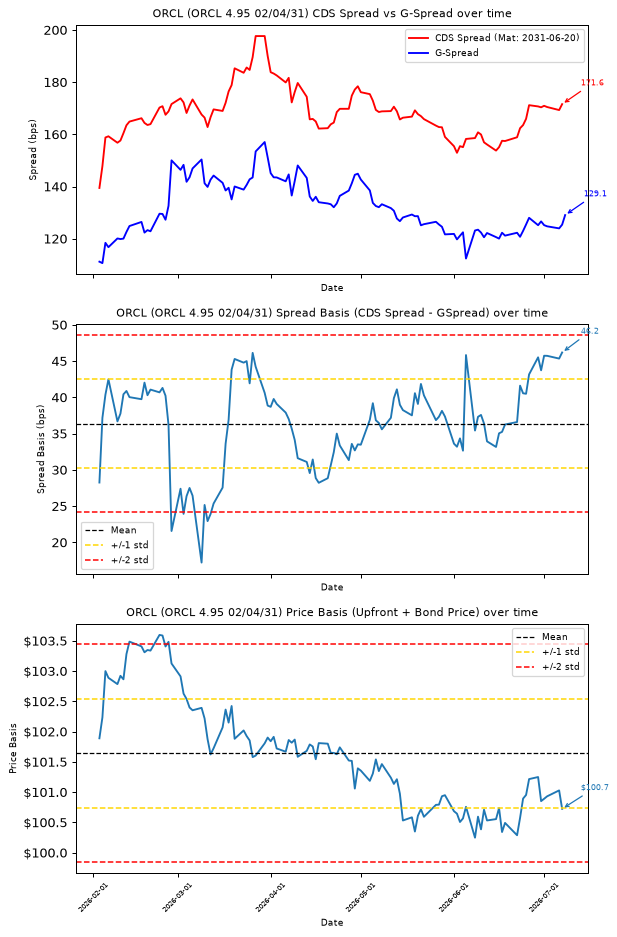

In [10]:
import sys
from pathlib import Path

# ── Locate project root and register the slideshow package ────────────────────
# Works whether the kernel CWD is notebooks/ or the project root.
for _candidate in [Path.cwd(), Path.cwd().parent]:
    if (_candidate / "slideshow" / "__init__.py").exists():
        if str(_candidate) not in sys.path:
            sys.path.insert(0, str(_candidate))
        break

from slideshow.plotting import plot_bond_cds_basis
from slideshow_utils    import run_slideshow
from IPython.display import Image

TICKER_TO_PLOT = "ORCL"

_, img_bytes = plot_bond_cds_basis(TICKER_TO_PLOT, bond_history)
display(Image(data=img_bytes))

#### Slideshow

In [11]:
CDS_INDEX_TO_PLOT = "IG"  # set to None to include all indices

ticker_index_df = (
    bond_history[["ticker", "cds_index"]]
    .dropna(subset=["ticker"])
    .drop_duplicates()
    .sort_values(["cds_index", "ticker"])
    .reset_index(drop=True)
)

ticker_list = (
    ticker_index_df[ticker_index_df["cds_index"] == CDS_INDEX_TO_PLOT]["ticker"].tolist()
    if CDS_INDEX_TO_PLOT is not None
    else ticker_index_df["ticker"].tolist()
)
len(ticker_list)

141

In [ ]:
START_TICKER = ''  # set to a ticker (e.g. "ORCL") to resume the slideshow from there

run_slideshow(
    items      = ticker_list,
    render_fn  = lambda t: plot_bond_cds_basis(t, bond_history),
    timer_secs = 5,
    start_item = START_TICKER,
)

Output()